# Project 3 — Spam Email Classifier \(ML-based NLP\)

> **Mục tiêu:** xây dựng một mô hình Machine Learning có thể phân loại text thành **Spam** hoặc **Ham / Not Spam**.

Trong project này, mình sẽ đi theo pipeline:

```text
Raw text
→ clean text
→ tokenization
→ TF-IDF vectorization
→ Logistic Regression / Naive Bayes
→ evaluation
→ error analysis
→ save model
```

## Bạn sẽ học được gì?

1. **NLP preprocessing**: làm sạch text, chuẩn hóa chữ, xử lý URL/email/số/ký tự đặc biệt.
2. **Tokenization**: tách câu thành các token/từ để máy tính xử lý.
3. **Vectorization**: biến text thành vector số bằng **TF-IDF**.
4. **Text classification**: train model phân loại spam/ham.
5. **Model evaluation**: đánh giá bằng Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix.
6. **Error analysis**: xem model sai ở đâu và vì sao sai.
7. **Save model**: lưu pipeline bằng `joblib` để dùng lại sau này.

---

## Ý tưởng trực giác

Máy tính không hiểu trực tiếp câu như:

```text
Congratulations! You won a free prize. Click here now!
```

Vì vậy ta phải biến câu này thành vector số. Sau đó model học pattern:

- Những từ như `free`, `win`, `prize`, `urgent`, `click` thường xuất hiện trong spam.
- Những từ như `meeting`, `home`, `thanks`, `see you` thường xuất hiện trong ham.

Project này là NLP nhưng vẫn dùng Machine Learning truyền thống, rất hợp để luyện trước khi bước sang Deep Learning/Transformer.


# 0. Setup môi trường

Chạy cell dưới để import các thư viện cần dùng.

Nếu máy bạn thiếu thư viện, mở terminal hoặc chạy trong notebook:

```python
!pip install pandas numpy matplotlib scikit-learn joblib
```


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup thành công!")


Setup thành công!


# 1. Chuẩn bị dataset

Bạn nên dùng dataset thật. Có 2 dạng dataset spam phổ biến:

## Dạng 1 — SMS Spam Collection
Thường có cột:

```text
v1: ham/spam
v2: message text
```

## Dạng 2 — Spam Email Dataset
Thường có cột:

```text
label: 0/1 hoặc ham/spam
text/message/email: nội dung email
```

Trong notebook này, mình viết hàm load khá linh hoạt để tự nhận diện nhiều kiểu tên cột khác nhau.

## Cấu trúc folder đề xuất

```text
project_3_spam_email_classifier/
├── spam_email_classifier.ipynb
├── data/
│   └── spam.csv
└── models/
```

Nếu chưa có dataset, notebook sẽ dùng một bộ demo rất nhỏ để bạn test pipeline. Nhưng khi làm project thật, bạn nên đặt file dataset thật vào `data/spam.csv`.


In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "email_spam" / "spam.csv"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Nếu DATA_PATH không tồn tại, notebook tự dùng demo data để không bị lỗi khi chạy thử.
USE_DEMO_DATA = not DATA_PATH.exists()

print("DATA_PATH:", DATA_PATH)
print("File tồn tại chưa?", DATA_PATH.exists())
print("USE_DEMO_DATA:", USE_DEMO_DATA)


DATA_PATH: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\email_spam\spam.csv
File tồn tại chưa? True
USE_DEMO_DATA: False


In [3]:
def create_demo_dataset() -> pd.DataFrame:
    """Tạo dataset nhỏ để test pipeline khi chưa tải data thật."""
    data = {
        "label": [
            "spam", "ham", "spam", "ham", "spam", "ham", "spam", "ham",
            "spam", "ham", "spam", "ham", "spam", "ham", "spam", "ham"
        ],
        "text": [
            "Congratulations! You won a free prize. Click now!",
            "Hey, are we still meeting for lunch today?",
            "URGENT! Claim your free cash reward now.",
            "Can you send me the report before 5pm?",
            "Win money now!!! Limited offer, click this link.",
            "Mom called. Please call her back when you can.",
            "You have been selected for a free gift card.",
            "Thanks for your help with the homework.",
            "Cheap meds available now. Buy today!",
            "Let's review the project plan tomorrow.",
            "Exclusive deal! Free entry in our contest.",
            "Don't forget the team meeting at 10.",
            "Claim your lottery prize by sending your details.",
            "I will arrive at the airport at 7pm.",
            "Act now! Your account won a bonus reward.",
            "Please check the attached lecture notes."
        ],
    }
    return pd.DataFrame(data)


def read_csv_flexible(path: Path) -> pd.DataFrame:
    """Đọc CSV với nhiều encoding thường gặp."""
    encodings = ["utf-8", "latin1", "ISO-8859-1"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def load_raw_dataset(path: Path, use_demo_data: bool = False) -> pd.DataFrame:
    if use_demo_data:
        print("Đang dùng demo dataset nhỏ. Khi làm thật, hãy đặt dataset vào data/spam.csv")
        return create_demo_dataset()
    return read_csv_flexible(path)

raw_df = load_raw_dataset(DATA_PATH, USE_DEMO_DATA)
print("Shape:", raw_df.shape)
display(raw_df.head())


Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


# 2. Chuẩn hóa dataset về format thống nhất

Mục tiêu của bước này là biến mọi dataset về dạng:

```text
text: nội dung email/SMS
label: 0 hoặc 1
```

Quy ước:

```text
0 = ham / not spam
1 = spam
```

Vì dataset trên mạng có thể đặt tên cột khác nhau, ta cần tự động tìm cột text và cột label.


In [4]:
POSSIBLE_TEXT_COLS = [
    "text", "message", "email", "sms", "content", "body", "mail", "v2",
    "Message", "Text", "Email", "Body"
]

POSSIBLE_LABEL_COLS = [
    "label", "category", "class", "target", "spam", "v1", "Label", "Category", "Class"
]


def find_column(df: pd.DataFrame, possible_names: list[str], column_type: str) -> str:
    """Tìm cột phù hợp dựa trên danh sách tên có thể gặp."""
    for col in possible_names:
        if col in df.columns:
            return col
    raise ValueError(
        f"Không tìm thấy cột {column_type}.\n"
        f"Các cột hiện có: {list(df.columns)}\n"
        "Bạn hãy đổi tên cột text thành 'text' và label thành 'label', rồi chạy lại."
    )


def normalize_label_value(x):
    """Đưa label về 0/1."""
    if pd.isna(x):
        return np.nan

    # Nếu label đã là số
    if isinstance(x, (int, float, np.integer, np.floating)):
        if int(x) == 1:
            return 1
        if int(x) == 0:
            return 0

    # Nếu label là chữ
    s = str(x).strip().lower()
    spam_values = {"spam", "1", "yes", "true", "junk", "phishing"}
    ham_values = {"ham", "0", "no", "false", "not spam", "non-spam", "legit", "normal"}

    if s in spam_values:
        return 1
    if s in ham_values:
        return 0

    return np.nan


def standardize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    text_col = find_column(df, POSSIBLE_TEXT_COLS, "text")
    label_col = find_column(df, POSSIBLE_LABEL_COLS, "label")

    clean_df = df[[text_col, label_col]].copy()
    clean_df.columns = ["text", "label"]

    clean_df["text"] = clean_df["text"].astype(str)
    clean_df["label"] = clean_df["label"].apply(normalize_label_value)

    before = len(clean_df)
    clean_df = clean_df.dropna(subset=["text", "label"])
    clean_df["label"] = clean_df["label"].astype(int)
    clean_df = clean_df.drop_duplicates(subset=["text", "label"])
    after = len(clean_df)

    print(f"Text column tìm được: {text_col}")
    print(f"Label column tìm được: {label_col}")
    print(f"Số dòng trước khi clean: {before}")
    print(f"Số dòng sau khi clean/drop duplicate: {after}")

    return clean_df.reset_index(drop=True)


df = standardize_dataset(raw_df)
print("Shape chuẩn hóa:", df.shape)
display(df.head())


Text column tìm được: v2
Label column tìm được: v1
Số dòng trước khi clean: 5572
Số dòng sau khi clean/drop duplicate: 5169
Shape chuẩn hóa: (5169, 2)


,text,label
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives around here though",0


# 3. EDA cho text data

EDA trong NLP không chỉ xem số dòng/cột. Ta nên xem thêm:

1. Tỷ lệ spam/ham có bị lệch không.
2. Text dài hay ngắn.
3. Spam có xu hướng dài hơn ham không.
4. Những từ nào xuất hiện nhiều.

Đây là bước giúp ta hiểu dữ liệu trước khi train model.


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5169 non-null   object
 1   label   5169 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 80.9+ KB
None

Label distribution:


,count
ham/not spam,4516
spam,653


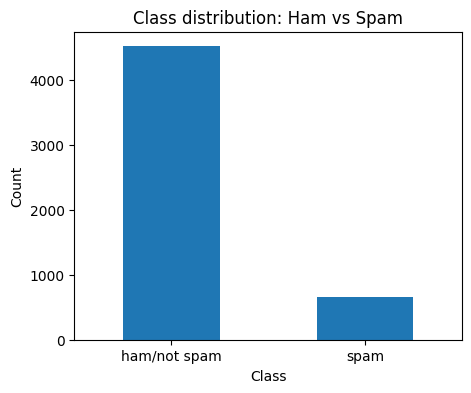

In [5]:
print("Thông tin dataset:")
print(df.info())

print("\nLabel distribution:")
label_counts = df["label"].value_counts().sort_index()
label_counts.index = ["ham/not spam", "spam"]
display(label_counts.to_frame("count"))

plt.figure(figsize=(5, 4))
label_counts.plot(kind="bar")
plt.title("Class distribution: Ham vs Spam")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Thống kê độ dài text theo label:


char_count                                                           \
           count        mean        std   min    25%    50%    75%    max   
label                                                                       
0         4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0   
1          653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
0         4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0  
1          653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0

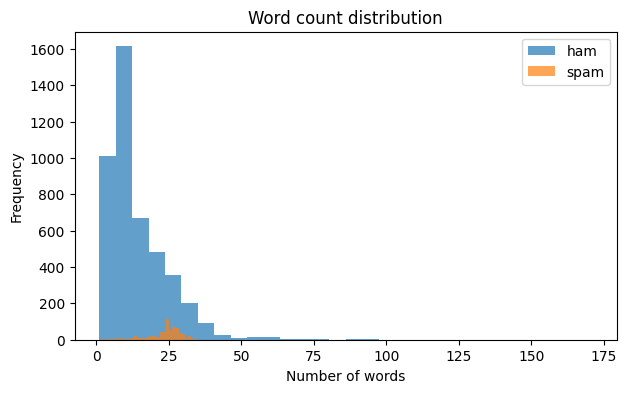

In [6]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Thống kê độ dài text theo label:")
display(df.groupby("label")[["char_count", "word_count"]].describe())

plt.figure(figsize=(7, 4))
plt.hist(df.loc[df["label"] == 0, "word_count"], bins=30, alpha=0.7, label="ham")
plt.hist(df.loc[df["label"] == 1, "word_count"], bins=30, alpha=0.7, label="spam")
plt.title("Word count distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# 4. Text preprocessing

Text preprocessing là bước làm sạch text trước khi đưa vào vectorizer.

Ví dụ:

```text
"WIN $$$ now!!! Visit https://abc.com"
```

Sau khi clean có thể thành:

```text
"win money now visit url"
```

## Các bước clean trong notebook này

1. Lowercase: chuyển về chữ thường.
2. Replace URL bằng token `url`.
3. Replace email bằng token `email`.
4. Replace số bằng token `number`.
5. Xóa dấu câu/ký tự đặc biệt.
6. Xóa khoảng trắng thừa.

Lưu ý: Trong NLP cổ điển, không phải lúc nào clean càng mạnh càng tốt. Ví dụ dấu `!!!` có thể là tín hiệu spam. Nhưng ở project beginner, clean như dưới là đủ tốt để hiểu pipeline.


In [7]:
def clean_text(text: str) -> str:
    """Làm sạch text cơ bản cho bài toán spam classification."""
    text = str(text).lower()

    # Thay URL/email/số bằng token chung
    text = re.sub(r"http\S+|www\.\S+", " url ", text)
    text = re.sub(r"\S+@\S+", " email ", text)
    text = re.sub(r"\d+", " number ", text)

    # Thay ký tự không phải chữ/số/_ bằng khoảng trắng
    text = re.sub(r"[^a-zA-Z_]+", " ", text)

    # Xóa khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()
    return text


examples = df[["text", "label"]].sample(min(5, len(df)), random_state=RANDOM_STATE).copy()
examples["clean_text"] = examples["text"].apply(clean_text)
display(examples)


,text,label,clean_text
1566,Did u download the fring app?,0,did u download the fring app
1988,Pass dis to all ur contacts n see wat u get! Red;i'm in luv wid u. Blue;u put a smile on my face. Purple;u r realy hot. Pink;u r so swt. Orange;i thnk i lyk...,0,pass dis to all ur contacts n see wat u get red i m in luv wid u blue u put a smile on my face purple u r realy hot pink u r so swt orange i thnk i lyk u gr...
1235,Ok...,0,ok
2868,Am in film ill call you later.,0,am in film ill call you later
3435,"Sorry, left phone upstairs. OK, might be hectic but would be all my birds with one fell swoop. It's a date.",0,sorry left phone upstairs ok might be hectic but would be all my birds with one fell swoop it s a date


# 5. Tokenization và Vectorization

## 5.1 Tokenization là gì?

**Tokenization** là tách câu thành các đơn vị nhỏ hơn, thường là từ/token.

Ví dụ:

```text
"win free prize now"
```

Có thể tách thành:

```text
["win", "free", "prize", "now"]
```

## 5.2 Vì sao cần vectorization?

Model ML như Logistic Regression hoặc Naive Bayes chỉ xử lý số, không xử lý trực tiếp text.

Vì vậy ta cần biến text thành vector số.

## 5.3 TF-IDF là gì?

**TF-IDF** = **Term Frequency - Inverse Document Frequency**.

Ý tưởng:

- Từ xuất hiện nhiều trong một email → quan trọng hơn.
- Nhưng nếu từ đó xuất hiện trong hầu hết mọi email → giảm độ quan trọng.

Ví dụ:

- `the`, `you`, `and` xuất hiện rất nhiều nhưng không quá đặc biệt.
- `free`, `winner`, `urgent`, `prize` có thể quan trọng hơn cho spam.


In [8]:
# Demo nhỏ để thấy CountVectorizer và TfidfVectorizer khác nhau như thế nào.
demo_texts = [
    "free prize now",
    "free meeting today",
    "project meeting today",
]

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(demo_texts)
count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)
print("Count Vectorizer demo:")
display(count_df)


tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(demo_texts)
tfidf_df = pd.DataFrame(
    np.round(tfidf_matrix.toarray(), 3),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("TF-IDF Vectorizer demo:")
display(tfidf_df)


Count Vectorizer demo:


,free,meeting,now,prize,project,today
0,1,0,1,1,0,0
1,1,1,0,0,0,1
2,0,1,0,0,1,1


TF-IDF Vectorizer demo:


,free,meeting,now,prize,project,today
0,0.474,0.000,0.623,0.623,0.000,0.000
1,0.577,0.577,0.000,0.000,0.000,0.577
2,0.000,0.518,0.000,0.000,0.681,0.518


# 6. Train/Test Split

Ta chia dữ liệu thành:

- **Train set**: dùng để model học.
- **Test set**: dùng để đánh giá model trên dữ liệu chưa thấy.

Vì đây là classification, ta dùng `stratify=y` để giữ tỷ lệ spam/ham tương đối giống nhau giữa train và test.


In [9]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if y.nunique() == 2 and y.value_counts().min() >= 2 else None,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train label distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("ratio"))
print("Test label distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("ratio"))


Train size: 4135
Test size: 1034
Train label distribution:


,ratio
label,
0,0.873761
1,0.126239


Test label distribution:


,ratio
label,
0,0.873308
1,0.126692


# 7. Build ML pipelines

Ta sẽ train 2 model:

## Model 1 — Logistic Regression

Ưu điểm:

- Dễ hiểu.
- Có thể xem feature nào kéo dự đoán về spam/ham.
- Thường mạnh với TF-IDF.

## Model 2 — Multinomial Naive Bayes

Ưu điểm:

- Rất phổ biến trong text classification cổ điển.
- Train nhanh.
- Hợp với dữ liệu dạng word count / TF-IDF không âm.

## Vì sao dùng `Pipeline`?

Pipeline giúp gom nhiều bước thành một object duy nhất:

```text
raw text → TF-IDF → model
```

Khi save model, ta save luôn cả preprocessing + vectorizer + classifier.


In [10]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean_text,
        lowercase=False,       # đã lowercase trong clean_text rồi
        stop_words="english",  # với dataset tiếng Anh
        ngram_range=(1, 2),    # unigram + bigram
        min_df=2 if len(df) >= 100 else 1,
        max_features=20_000,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
])

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=clean_text,
        lowercase=False,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2 if len(df) >= 100 else 1,
        max_features=20_000,
    )),
    ("clf", MultinomialNB())
])

models = {
    "Logistic Regression": lr_pipeline,
    "Multinomial Naive Bayes": nb_pipeline,
}

models


{'Logistic Regression': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(lowercase=False, max_features=20000, min_df=2,
                                  ngram_range=(1, 2),
                                  preprocessor=<function clean_text at 0x000001944F7ADCF0>,
                                  stop_words='english')),
                 ('clf',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'Multinomial Naive Bayes': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(lowercase=False, max_features=20000, min_df=2,
                                  ngram_range=(1, 2),
                                  preprocessor=<function clean_text at 0x000001944F7ADCF0>,
                                  stop_words='english')),
                 ('clf', MultinomialNB())])}

# 8. Train model

Ở bước này, mỗi pipeline sẽ học trên train set.

Với Logistic Regression:

```text
TF-IDF vector → học weight cho từng feature/token
```

Với Naive Bayes:

```text
TF-IDF vector → học xác suất token xuất hiện trong spam/ham
```


In [11]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Đã train xong: {name}")


Đã train xong: Logistic Regression
Đã train xong: Multinomial Naive Bayes


# 9. Evaluation

Với spam classifier, ta không chỉ nhìn Accuracy.

## Các metric quan trọng

- **Accuracy**: tổng thể đoán đúng bao nhiêu phần trăm.
- **Precision**: trong các email model dự đoán là spam, có bao nhiêu cái thật sự là spam.
- **Recall**: trong toàn bộ spam thật, model bắt được bao nhiêu cái.
- **F1-score**: cân bằng giữa precision và recall.
- **ROC-AUC**: khả năng model phân biệt spam/ham ở nhiều threshold khác nhau.

## Trong spam classifier, sai lầm nào nguy hiểm hơn?

Tùy ứng dụng:

- **False Positive**: email bình thường bị đưa vào spam. Có thể nguy hiểm vì người dùng mất email quan trọng.
- **False Negative**: spam lọt vào inbox. Gây phiền, có thể nguy hiểm nếu là phishing.

Trong thực tế, email system thường rất sợ **False Positive**, vì chặn nhầm email quan trọng sẽ gây khó chịu lớn.


In [12]:
def get_positive_scores(model, X_data):
    """Lấy score/xác suất cho class spam = 1."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return None


def evaluate_model(name: str, model, X_data, y_true, threshold: float = 0.5, show_matrix: bool = True):
    scores = get_positive_scores(model, X_data)

    if scores is not None:
        y_pred = (scores >= threshold).astype(int)
    else:
        y_pred = model.predict(X_data)

    result = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if scores is not None and len(np.unique(y_true)) == 2:
        result["roc_auc"] = roc_auc_score(y_true, scores)
    else:
        result["roc_auc"] = np.nan

    print(f"\n===== {name} =====")
    print(pd.Series(result))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"], zero_division=0))

    if show_matrix:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix — {name}")
        plt.show()

    return result



===== Logistic Regression =====
model        Logistic Regression
threshold                    0.5
accuracy                0.971954
precision               0.844595
recall                  0.954198
f1                      0.896057
roc_auc                 0.988791
dtype: object

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       903
        spam       0.84      0.95      0.90       131

    accuracy                           0.97      1034
   macro avg       0.92      0.96      0.94      1034
weighted avg       0.97      0.97      0.97      1034



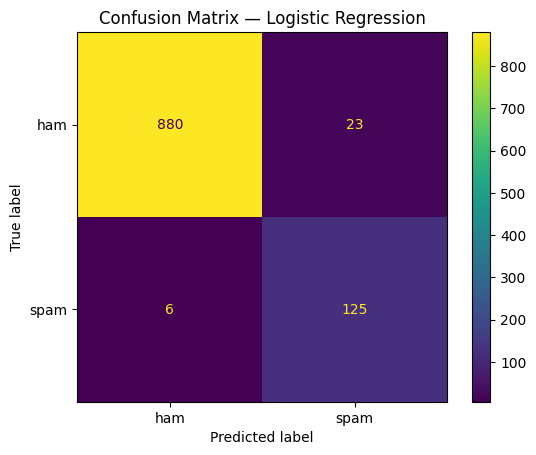


===== Multinomial Naive Bayes =====
model        Multinomial Naive Bayes
threshold                        0.5
accuracy                    0.976789
precision                        1.0
recall                      0.816794
f1                           0.89916
roc_auc                     0.992519
dtype: object

Classification report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       903
        spam       1.00      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034



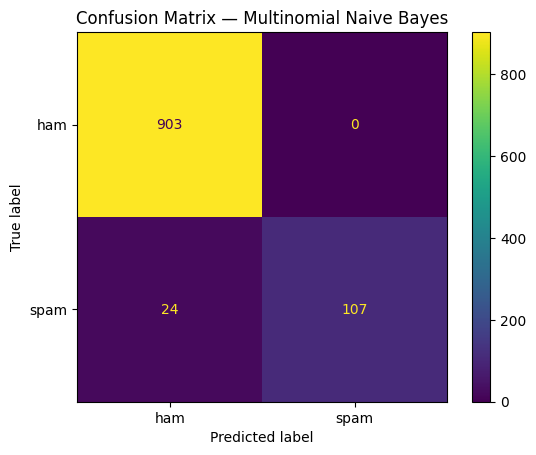

,model,threshold,accuracy,precision,recall,f1,roc_auc
1,Multinomial Naive Bayes,0.5,0.976789,1.000000,0.816794,0.899160,0.992519
0,Logistic Regression,0.5,0.971954,0.844595,0.954198,0.896057,0.988791


In [13]:
results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_test, y_test, threshold=0.5, show_matrix=True))

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)


# 10. Cross-validation

Train/test split chỉ đánh giá trên một lần chia dữ liệu.

**Cross-validation** giúp đánh giá ổn định hơn:

```text
Dataset chia thành nhiều fold
→ train nhiều lần
→ lấy trung bình metric
```

Với dataset nhỏ, cross-validation rất hữu ích vì kết quả train/test có thể dao động nhiều.


In [14]:
if len(df) >= 50 and y.value_counts().min() >= 5:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    cv_rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"model": name}
        for metric in scoring:
            row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std()
        cv_rows.append(row)

    cv_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
    display(cv_df)
else:
    print("Dataset quá nhỏ để chạy cross-validation có ý nghĩa. Hãy dùng dataset thật rồi chạy lại cell này.")


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,Multinomial Naive Bayes,0.978139,0.002333,1.000000,0.000000,0.826999,0.018036,0.905201,0.010910,0.989689,0.005308
0,Logistic Regression,0.966917,0.002970,0.822782,0.018381,0.941773,0.021515,0.877943,0.010457,0.986182,0.004753


# 11. Hyperparameter tuning

Ta tuning một vài tham số đơn giản:

## TF-IDF

- `ngram_range`: dùng 1 từ hay cụm 2 từ.
- `min_df`: bỏ qua từ xuất hiện quá ít.
- `max_features`: giới hạn số lượng feature.

## Logistic Regression

- `C`: độ mạnh regularization. C nhỏ hơn nghĩa là regularization mạnh hơn.

## Naive Bayes

- `alpha`: smoothing, tránh xác suất bằng 0.

Lưu ý: tuning có thể tốn thời gian nếu dataset lớn.


In [15]:
RUN_GRID_SEARCH = False  # Đổi thành True nếu bạn muốn tuning kỹ hơn.

if RUN_GRID_SEARCH and len(df) >= 100 and y.value_counts().min() >= 5:
    lr_param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_features": [5_000, 10_000, 20_000],
        "clf__C": [0.1, 1, 3, 10],
    }

    lr_grid = GridSearchCV(
        lr_pipeline,
        lr_param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )
    lr_grid.fit(X_train, y_train)

    print("Best LR params:", lr_grid.best_params_)
    print("Best LR CV F1:", lr_grid.best_score_)

    tuned_lr = lr_grid.best_estimator_
    evaluate_model("Tuned Logistic Regression", tuned_lr, X_test, y_test)
else:
    print("Grid search đang tắt hoặc dataset chưa đủ lớn.")
    print("Khi muốn tuning, đổi RUN_GRID_SEARCH = True rồi chạy lại.")


Grid search đang tắt hoặc dataset chưa đủ lớn.
Khi muốn tuning, đổi RUN_GRID_SEARCH = True rồi chạy lại.


In [16]:
if RUN_GRID_SEARCH and len(df) >= 100 and y.value_counts().min() >= 5:
    nb_param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_features": [5_000, 10_000, 20_000],
        "clf__alpha": [0.1, 0.5, 1.0, 2.0],
    }

    nb_grid = GridSearchCV(
        nb_pipeline,
        nb_param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )
    nb_grid.fit(X_train, y_train)

    print("Best NB params:", nb_grid.best_params_)
    print("Best NB CV F1:", nb_grid.best_score_)

    tuned_nb = nb_grid.best_estimator_
    evaluate_model("Tuned Naive Bayes", tuned_nb, X_test, y_test)
else:
    print("Grid search cho Naive Bayes đang tắt hoặc dataset chưa đủ lớn.")


Grid search cho Naive Bayes đang tắt hoặc dataset chưa đủ lớn.


# 12. Chọn best model

Ở bước này ta chọn model tốt nhất dựa trên F1-score.

Trong spam classifier, có thể bạn sẽ ưu tiên metric khác:

- Muốn ít chặn nhầm email bình thường → ưu tiên **Precision cao**.
- Muốn bắt nhiều spam nhất → ưu tiên **Recall cao**.
- Muốn cân bằng → ưu tiên **F1-score**.


In [17]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best model theo F1-score:", best_model_name)
display(results_df)


Best model theo F1-score: Multinomial Naive Bayes


,model,threshold,accuracy,precision,recall,f1,roc_auc
1,Multinomial Naive Bayes,0.5,0.976789,1.000000,0.816794,0.899160,0.992519
0,Logistic Regression,0.5,0.971954,0.844595,0.954198,0.896057,0.988791


# 13. Threshold tuning

Mặc định, model phân loại spam nếu:

```text
P(spam) >= 0.5
```

Nhưng threshold 0.5 không phải lúc nào cũng tối ưu.

Ví dụ:

- Threshold cao hơn, ví dụ 0.8 → model chỉ báo spam khi rất chắc chắn → Precision tăng, Recall có thể giảm.
- Threshold thấp hơn, ví dụ 0.3 → model bắt nhiều spam hơn → Recall tăng, Precision có thể giảm.



===== Multinomial Naive Bayes =====
model        Multinomial Naive Bayes
threshold                        0.2
accuracy                     0.98646
precision                   0.953488
recall                      0.938931
f1                          0.946154
roc_auc                     0.992519
dtype: object

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.95      0.94      0.95       131

    accuracy                           0.99      1034
   macro avg       0.97      0.97      0.97      1034
weighted avg       0.99      0.99      0.99      1034


===== Multinomial Naive Bayes =====
model        Multinomial Naive Bayes
threshold                        0.3
accuracy                    0.983559
precision                   0.983051
recall                      0.885496
f1                          0.931727
roc_auc                     0.992519
dtype: object

Classification report:
     

,threshold,accuracy,precision,recall,f1,roc_auc
0,0.2,0.986460,0.953488,0.938931,0.946154,0.992519
1,0.3,0.983559,0.983051,0.885496,0.931727,0.992519
2,0.4,0.980658,0.991150,0.854962,0.918033,0.992519
3,0.5,0.976789,1.000000,0.816794,0.899160,0.992519
4,0.6,0.970986,1.000000,0.770992,0.870690,0.992519
5,0.7,0.965184,1.000000,0.725191,0.840708,0.992519
6,0.8,0.956480,1.000000,0.656489,0.792627,0.992519


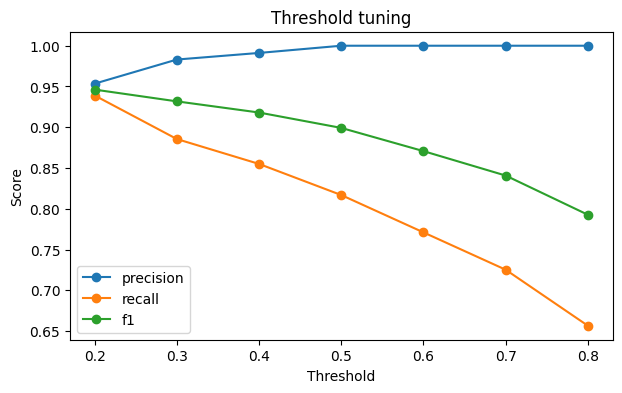

In [18]:
threshold_rows = []
thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds_to_try:
    row = evaluate_model(
        best_model_name,
        best_model,
        X_test,
        y_test,
        threshold=threshold,
        show_matrix=False,
    )
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[["threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]])

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.title("Threshold tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()


# 14. Error analysis

Đây là phần rất quan trọng để project nhìn có chiều sâu hơn.

Ta sẽ xem:

## False Positive

Email bình thường nhưng model dự đoán là spam.

```text
true label = ham
predicted = spam
```

## False Negative

Email spam nhưng model dự đoán là bình thường.

```text
true label = spam
predicted = ham
```

Khi phân tích lỗi, bạn nên đọc text và tự hỏi:

- Text có chứa từ dễ gây hiểu nhầm không?
- Email spam có quá giống email bình thường không?
- Có cần thêm dữ liệu không?
- Có cần thay đổi threshold không?


In [19]:
def make_error_analysis_df(model, X_data, y_true, threshold=0.5) -> pd.DataFrame:
    scores = get_positive_scores(model, X_data)
    if scores is not None:
        y_pred = (scores >= threshold).astype(int)
    else:
        y_pred = model.predict(X_data)
        scores = np.full(len(y_pred), np.nan)

    error_df = pd.DataFrame({
        "text": X_data.values,
        "y_true": y_true.values,
        "y_pred": y_pred,
        "spam_score": scores,
    })
    error_df["error_type"] = np.where(
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1), "False Positive",
        np.where((error_df["y_true"] == 1) & (error_df["y_pred"] == 0), "False Negative", "Correct")
    )
    return error_df

error_df = make_error_analysis_df(best_model, X_test, y_test, threshold=0.5)

print("Số lượng từng loại lỗi:")
display(error_df["error_type"].value_counts().to_frame("count"))

print("\nFalse Positive examples:")
display(error_df[error_df["error_type"] == "False Positive"].sort_values("spam_score", ascending=False).head(10))

print("\nFalse Negative examples:")
display(error_df[error_df["error_type"] == "False Negative"].sort_values("spam_score", ascending=True).head(10))


Số lượng từng loại lỗi:


,count
error_type,
Correct,1010
False Negative,24



False Positive examples:


,text,y_true,y_pred,spam_score,error_type



False Negative examples:


,text,y_true,y_pred,spam_score,error_type
437,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs),1,0,0.022072,False Negative
486,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)",1,0,0.026831,False Negative
456,Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo,1,0,0.071482,False Negative
544,"Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're selling fast!",1,0,0.076121,False Negative
326,Missed call alert. These numbers called but left no message. 07008009200,1,0,0.112224,False Negative
160,"Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603",1,0,0.161801,False Negative
329,SMS. ac sun0819 posts HELLO:\You seem cool,1,0,0.163672,False Negative
230,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O å£250 3 WANT å...,1,0,0.196471,False Negative
992,Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winner,1,0,0.240126,False Negative
726,Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min,1,0,0.247551,False Negative


# 15. Interpret model: từ nào quan trọng?

Với Logistic Regression, ta có thể xem weight của từng token.

- Weight dương lớn → token kéo dự đoán về **spam**.
- Weight âm lớn → token kéo dự đoán về **ham**.

Phần này giúp project không chỉ có train/evaluate mà còn có giải thích model.


In [20]:
def show_logistic_regression_top_features(model, top_n=20):
    clf = model.named_steps.get("clf")
    tfidf = model.named_steps.get("tfidf")

    if not isinstance(clf, LogisticRegression):
        print("Model hiện tại không phải Logistic Regression, bỏ qua phần coefficient interpretation.")
        return

    feature_names = np.array(tfidf.get_feature_names_out())
    coef = clf.coef_[0]

    top_spam_idx = np.argsort(coef)[-top_n:][::-1]
    top_ham_idx = np.argsort(coef)[:top_n]

    top_spam = pd.DataFrame({
        "token": feature_names[top_spam_idx],
        "coefficient": coef[top_spam_idx],
        "direction": "spam"
    })

    top_ham = pd.DataFrame({
        "token": feature_names[top_ham_idx],
        "coefficient": coef[top_ham_idx],
        "direction": "ham"
    })

    print("Top tokens kéo về SPAM:")
    display(top_spam)

    print("Top tokens kéo về HAM:")
    display(top_ham)


show_logistic_regression_top_features(best_model, top_n=20)


Model hiện tại không phải Logistic Regression, bỏ qua phần coefficient interpretation.


# 16. Predict email mới

Sau khi train xong, ta có thể nhập text mới và để model dự đoán.


In [22]:
def predict_spam(text: str, model=best_model, threshold: float = 0.5) -> dict:
    score = get_positive_scores(model, pd.Series([text]))[0]
    prediction = int(score >= threshold)
    return {
        "text": text,
        "spam_probability": float(score),
        "threshold": threshold,
        "prediction": "spam" if prediction == 1 else "ham/not spam",
    }

sample_emails = [
    "Congratulations! You have won a free iPhone. Click this link now!",
    "Hi, can we move our meeting to 3pm tomorrow?",
    "URGENT: Your account has been selected for a cash reward.",
    "Hello, how are you doing?",
]

predictions = [predict_spam(text, threshold=0.5) for text in sample_emails]
display(pd.DataFrame(predictions))


,text,spam_probability,threshold,prediction
0,Congratulations! You have won a free iPhone. Click this link now!,0.638257,0.5,spam
1,"Hi, can we move our meeting to 3pm tomorrow?",0.033962,0.5,ham/not spam
2,URGENT: Your account has been selected for a cash reward.,0.683718,0.5,spam
3,"Hello, how are you doing?",0.012106,0.5,ham/not spam


# 17. Save model

Vì ta dùng `Pipeline`, khi save model là save toàn bộ:

```text
clean text + TF-IDF + classifier
```

Sau này load lại chỉ cần đưa raw text vào là predict được.


In [23]:
MODEL_PATH = BASE_DIR / "models" / "spam_email" / "spam_email_classifier_pipeline.joblib"
METADATA_PATH = BASE_DIR / "models" / "spam_email" / "spam_email_classifier_metadata.joblib"

metadata = {
    "project": "Project 3 — Spam Email Classifier",
    "best_model_name": best_model_name,
    "label_mapping": {0: "ham/not spam", 1: "spam"},
    "threshold_default": 0.5,
    "metrics": results_df.to_dict(orient="records"),
}

joblib.dump(best_model, MODEL_PATH)
joblib.dump(metadata, METADATA_PATH)

print("Đã lưu model tại:", MODEL_PATH)
print("Đã lưu metadata tại:", METADATA_PATH)


Đã lưu model tại: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\spam_email\spam_email_classifier_pipeline.joblib
Đã lưu metadata tại: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\spam_email\spam_email_classifier_metadata.joblib


In [24]:
# Test load model lại
loaded_model = joblib.load(MODEL_PATH)
loaded_metadata = joblib.load(METADATA_PATH)

print("Loaded metadata:")
display(loaded_metadata)

text = "Free prize! Claim your reward now."
score = loaded_model.predict_proba([text])[:, 1][0]
pred = "spam" if score >= loaded_metadata["threshold_default"] else "ham/not spam"

print("Text:", text)
print("Spam probability:", round(score, 4))
print("Prediction:", pred)


Loaded metadata:


{'project': 'Project 3 — Spam Email Classifier',
 'best_model_name': 'Multinomial Naive Bayes',
 'label_mapping': {0: 'ham/not spam', 1: 'spam'},
 'threshold_default': 0.5,
 'metrics': [{'model': 'Multinomial Naive Bayes',
   'threshold': 0.5,
   'accuracy': 0.97678916827853,
   'precision': 1.0,
   'recall': 0.816793893129771,
   'f1': 0.8991596638655462,
   'roc_auc': 0.9925185767543303},
  {'model': 'Logistic Regression',
   'threshold': 0.5,
   'accuracy': 0.971953578336557,
   'precision': 0.8445945945945946,
   'recall': 0.9541984732824428,
   'f1': 0.8960573476702509,
   'roc_auc': 0.988790545509878}]}

Text: Free prize! Claim your reward now.
Spam probability: 0.8966
Prediction: spam


# 18. Mini report template

Sau khi chạy project, bạn có thể viết báo cáo ngắn theo format này:

```text
Project: Spam Email Classifier

1. Problem
Mục tiêu là phân loại email/SMS thành spam hoặc ham.

2. Dataset
Dataset gồm ... dòng, trong đó ... spam và ... ham.

3. Preprocessing
- Lowercase
- Replace URL/email/number
- Remove special characters
- TF-IDF vectorization

4. Models
- Logistic Regression
- Multinomial Naive Bayes

5. Evaluation
Model tốt nhất là ... với:
- Accuracy: ...
- Precision: ...
- Recall: ...
- F1-score: ...
- ROC-AUC: ...

6. Error analysis
Model thường nhầm ở các trường hợp ...
False Positive nghĩa là ...
False Negative nghĩa là ...

7. Conclusion
Mô hình có thể dùng làm baseline tốt cho spam detection. Bước nâng cấp tiếp theo là tuning threshold, thêm dữ liệu, thử SVM hoặc deploy bằng FastAPI/Streamlit.
```


# 19. Checklist hoàn thành project

Bạn hoàn thành project này khi làm được các việc sau:

- [ ] Load được dataset thật.
- [ ] Chuẩn hóa được cột `text` và `label`.
- [ ] Hiểu tỷ lệ spam/ham trong dataset.
- [ ] Viết được hàm `clean_text`.
- [ ] Hiểu tokenization là gì.
- [ ] Hiểu TF-IDF dùng để làm gì.
- [ ] Train được Logistic Regression.
- [ ] Train được Multinomial Naive Bayes.
- [ ] So sánh được metrics của 2 model.
- [ ] Đọc được Confusion Matrix.
- [ ] Phân tích được False Positive và False Negative.
- [ ] Thử threshold tuning.
- [ ] Predict được email mới.
- [ ] Save/load được model bằng `joblib`.

---

# 20. Bài tập tự luyện

Không có đáp án ở đây để bạn tự luyện trước.

## Bài 1
Thay `ngram_range=(1, 2)` thành `(1, 1)`. So sánh F1-score thay đổi thế nào.

## Bài 2
Bỏ `stop_words="english"`. So sánh kết quả.

## Bài 3
Thử thêm model `LinearSVC` hoặc `RandomForestClassifier`. Model nào tốt hơn?

## Bài 4
Thay đổi threshold thành 0.3, 0.5, 0.7. Trường hợp nào Precision cao hơn? Trường hợp nào Recall cao hơn?

## Bài 5
Đọc 5 False Positive và 5 False Negative. Viết nhận xét vì sao model có thể nhầm.
